# Đánh giá gợi ý Home

Bài toán Home là **cá nhân hóa theo lịch sử người dùng**, không phải tìm sản phẩm giống nhau hay hoàn thiện outfit. Notebook dùng Amazon Fashion: 646 validation cases để tuning và 100 final cases để báo cáo. Baseline là **Most Popular**.

## Công thức

Baseline: $S_{popular}(i)=\log(1+n_i)/\log(1+n_{max})$.

Công thức cần tuning: $S_{home}=\alpha S_{preference}+(1-\alpha)S_{popularity}$.

Preference profile sử dụng category, brand, gender, color và price bucket. Nguyên lý content-based tham khảo Pazzani & Billsus (2007), DOI: 10.1007/978-3-540-72079-9_10. Hệ số là kết quả của đề tài, không lấy từ tài liệu. Business không được tuning vì Amazon không có tín hiệu sale/new-arrival tương đương production.

In [1]:
from pathlib import Path
from collections import Counter
from html import escape
from IPython.display import HTML, SVG, display
import json, math, time

def root():
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p/'backend').is_dir() and (p/'evaluation'/'recommendation').is_dir(): return p
    raise FileNotFoundError('Repository root not found')
ROOT=root(); EVAL=ROOT/'evaluation'/'recommendation'
def load(p): return json.loads(p.read_text(encoding='utf-8'))
def table(rows, cols):
    f=lambda v: f'{v:.6f}' if isinstance(v,float) else str(v)
    h=''.join(f'<th style="padding:6px">{escape(c)}</th>' for c in cols)
    b=''.join('<tr>'+''.join(f'<td style="padding:6px;border-top:1px solid #ddd">{escape(f(r[c]))}</td>' for c in cols)+'</tr>' for r in rows)
    display(HTML(f'<table><tr>{h}</tr>{b}</table>'))
def line_chart(rows,x_key,y_key,title,x_label,y_label):
    width,height,left,right,top,bottom=760,330,70,25,45,55
    xs=[r[x_key] for r in rows];ys=[r[y_key] for r in rows];xmin,xmax=min(xs),max(xs);ymax=max(ys)*1.08 or 1
    sx=lambda x:left+(x-xmin)/(xmax-xmin)*(width-left-right);sy=lambda y:height-bottom-y/ymax*(height-top-bottom)
    points=' '.join(f'{sx(r[x_key]):.1f},{sy(r[y_key]):.1f}' for r in rows);best=max(rows,key=lambda r:r[y_key])
    p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="22" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>']
    p += [f'<line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#111" opacity=".5"/>',f'<line x1="{left}" y1="{height-bottom}" x2="{width-right}" y2="{height-bottom}" stroke="#111" opacity=".5"/>']
    for i in range(5):
        y=ymax*i/4;py=sy(y);x=xmin+(xmax-xmin)*i/4;px=sx(x);p += [f'<line x1="{left}" y1="{py:.1f}" x2="{width-right}" y2="{py:.1f}" stroke="#111" opacity=".12"/>',f'<text x="{left-8}" y="{py+4:.1f}" text-anchor="end" fill="#111" font-size="11">{y:.3f}</text>',f'<text x="{px:.1f}" y="{height-bottom+20}" text-anchor="middle" fill="#111" font-size="11">{x:.2f}</text>']
    p += [f'<polyline points="{points}" fill="none" stroke="#2563eb" stroke-width="2"/>',f'<circle cx="{sx(best[x_key]):.1f}" cy="{sy(best[y_key]):.1f}" r="5" fill="#dc2626"/>',f'<text x="{sx(best[x_key])-8:.1f}" y="{sy(best[y_key])-10:.1f}" text-anchor="end" fill="#111" font-size="11">best {best[x_key]:.3f} / {best[y_key]:.4f}</text>',f'<text x="{width/2}" y="{height-8}" text-anchor="middle" fill="#111" font-size="12">{escape(x_label)}</text>',f'<text transform="translate(15 {height/2}) rotate(-90)" text-anchor="middle" fill="#111" font-size="12">{escape(y_label)}</text>','</svg>'];display(SVG(''.join(p)))
def bar_chart(rows,label_key,value_key,title):
    width,label_w,row_h=760,250,34;height=48+row_h*len(rows);maximum=max(r[value_key] for r in rows) or 1
    p=[f'<svg width="100%" viewBox="0 0 {width} {height}" role="img" style="background:#fff;color:#111"><title>{escape(title)}</title><rect width="100%" height="100%" fill="#fff"/>',f'<text x="{width/2}" y="20" text-anchor="middle" fill="#111" font-size="16">{escape(title)}</text>']
    for i,r in enumerate(rows):
        y=35+i*row_h;bw=(width-label_w-75)*r[value_key]/maximum;p += [f'<text x="{label_w-8}" y="{y+17}" text-anchor="end" fill="#111" font-size="11">{escape(str(r[label_key]))}</text>',f'<rect x="{label_w}" y="{y}" width="{bw:.1f}" height="22" fill="#2563eb"/>',f'<text x="{label_w+bw+6:.1f}" y="{y+16}" fill="#111" font-size="11">{r[value_key]:.4f}</text>']
    p.append('</svg>');display(SVG(''.join(p)))
val=[c for c in load(EVAL/'data'/'processed'/'amazon-fashion-home-validation-1000.json')['cases'] if c['context']=='home']
final=[c for c in load(EVAL/'data'/'processed'/'amazon-fashion-final-test.json')['cases'] if c['context']=='home']
print('validation=',len(val),'final=',len(final))

validation= 646 final= 100


In [2]:
CAT_PENALTY, BRAND_PENALTY = 0.08, 0.04
def rank(case, preference_weight, k):
    remaining=sorted([(preference_weight*x['signals']['preferenceMatch']+(1-preference_weight)*x['signals']['popularity'],x) for x in case['candidates']],key=lambda z:(-z[0],z[1]['productId']))
    picked=[]; cats=Counter(); brands=Counter()
    while remaining and len(picked)<k:
        bi=0; bs=-math.inf
        for i,(score,x) in enumerate(remaining):
            cat=x.get('categoryId') or 'unknown:'+x['productId']; brand=x.get('brandId') or 'unknown:'+x['productId']
            adjusted=score-CAT_PENALTY*cats[cat]-BRAND_PENALTY*brands[brand]
            if adjusted>bs: bi,bs=i,adjusted
        _,x=remaining.pop(bi); picked.append(x); cats[x.get('categoryId') or 'unknown:'+x['productId']]+=1; brands[x.get('brandId') or 'unknown:'+x['productId']]+=1
    return picked
def evaluate(cases,w,k=5):
    hits=ndcg=ap=0.; rec=set(); catalog=set()
    for c in cases:
        rel=set(c['relevantProductIds']); catalog.update(x['productId'] for x in c['candidates']); ranked=rank(c,w,k); first=0
        for i,x in enumerate(ranked,1):
            rec.add(x['productId'])
            if x['productId'] in rel and not first: first=i
        if first: hits+=1; ap+=1/first; ndcg+=1/math.log2(first+1)
    n=len(cases); return {'cases':n,'HR':hits/n,'NDCG':ndcg/n,'MAP':ap/n,'Coverage':len(rec)/len(catalog)}
assert all(len(c['candidates'])==200 for c in val+final)

## Grid search và 5-fold audit

Quét toàn bộ 201 giá trị $\alpha$ từ 0 đến 1 với bước 0.005; mỗi giá trị xác định duy nhất cặp `(preference, popularity)`. Bảng audit và biểu đồ xếp hạng bên dưới xác nhận đủ 201/201 cấu hình đã được đánh giá. Objective là NDCG@5, sau đó HR, MAP và coverage.

stage,step,expected,evaluated,unique,failed
Full grid,0.005000,201,201,201,0


searched= 201 seconds= 49.7 BEST= 1.0


preference,popularity,HR,NDCG,MAP,Coverage
1.000000,0.000000,0.089783,0.062986,0.054180,0.220833
0.995000,0.005000,0.086687,0.061343,0.053019,0.162587
0.990000,0.010000,0.086687,0.061343,0.053019,0.161872
0.985000,0.015000,0.086687,0.061275,0.052941,0.161158
0.980000,0.020000,0.086687,0.061207,0.052864,0.161158
0.975000,0.025000,0.085139,0.059969,0.051703,0.160800
0.970000,0.030000,0.083591,0.059195,0.051187,0.159907
0.965000,0.035000,0.083591,0.058556,0.050335,0.159728
0.960000,0.040000,0.082043,0.057754,0.049768,0.158835
0.955000,0.045000,0.082043,0.057540,0.049510,0.158656


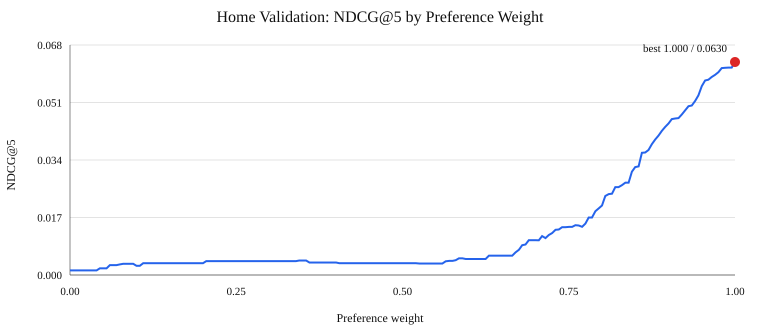

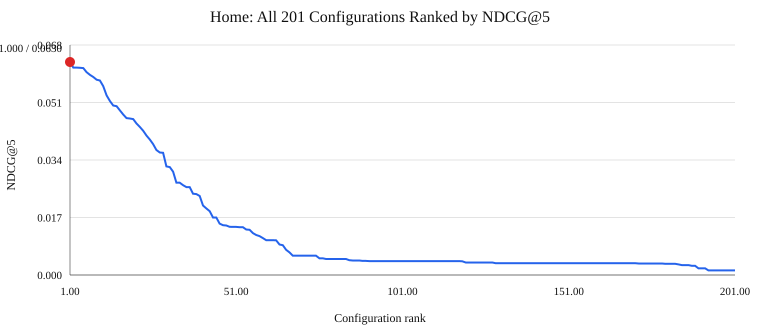

fold,cases,project_HR,popular_HR,project_NDCG,popular_NDCG
1,130,0.092308,0.000000,0.060181,0.000000
2,129,0.077519,0.007752,0.051678,0.003876
3,129,0.116279,0.000000,0.077492,0.000000
4,129,0.108527,0.007752,0.083365,0.002999
5,129,0.054264,0.000000,0.042236,0.000000


In [3]:
started=time.perf_counter(); search=[]
for i in range(201):
    w=i/200; search.append({'preference':w,'popularity':1-w,**evaluate(val,w,5)})
best=max(search,key=lambda r:(r['NDCG'],r['HR'],r['MAP'],r['Coverage'])); BEST=best['preference']
unique_search={(r['preference'],r['popularity']) for r in search}
search_audit=[{'stage':'Full grid','step':0.005,'expected':201,'evaluated':len(search),'unique':len(unique_search),'failed':0}]
table(search_audit,['stage','step','expected','evaluated','unique','failed'])
assert len(search)==len(unique_search)==201
print('searched=',len(search),'seconds=',round(time.perf_counter()-started,1),'BEST=',BEST)
table(sorted(search,key=lambda r:(r['NDCG'],r['HR'],r['MAP'],r['Coverage']),reverse=True)[:10],['preference','popularity','HR','NDCG','MAP','Coverage'])
line_chart(search,'preference','NDCG','Home Validation: NDCG@5 by Preference Weight','Preference weight','NDCG@5')
ranked_search=[{'rank':i,'NDCG':r['NDCG']} for i,r in enumerate(sorted(search,key=lambda r:r['NDCG'],reverse=True),1)]
line_chart(ranked_search,'rank','NDCG','Home: All 201 Configurations Ranked by NDCG@5','Configuration rank','NDCG@5')
folds=[]
for f in range(5):
    cases=[c for i,c in enumerate(val) if i%5==f]; a=evaluate(cases,BEST); b=evaluate(cases,0)
    folds.append({'fold':f+1,'cases':len(cases),'project_HR':a['HR'],'popular_HR':b['HR'],'project_NDCG':a['NDCG'],'popular_NDCG':b['NDCG']})
table(folds,list(folds[0]))

## Final test

So sánh công thức validation-optimal với Most Popular. Không báo một metric giả cho `business`: Amazon không có tín hiệu này, nên tỷ lệ 10% business của production chỉ được ghi như ràng buộc triển khai, không được xem là đã đánh giá offline.

K,method,cases,HR,NDCG,MAP,Coverage
5,Home optimized,100,0.080000,0.061487,0.055333,0.077881
5,Most Popular,100,0.010000,0.006309,0.005000,0.001358
10,Home optimized,100,0.120000,0.074428,0.060679,0.132216
10,Most Popular,100,0.010000,0.006309,0.005000,0.002490


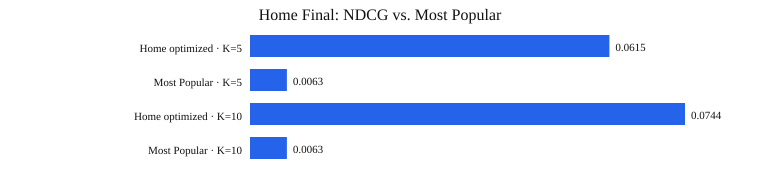

In [4]:
rows=[]
for k in (5,10):
    for name,w in [('Home optimized',BEST),('Most Popular',0.0)]: rows.append({'K':k,'method':name,**evaluate(final,w,k)})
table(rows,['K','method','cases','HR','NDCG','MAP','Coverage'])
bar_chart([{'label':f"{r['method']} · K={r['K']}",'NDCG':r['NDCG']} for r in rows],'label','NDCG','Home Final: NDCG vs. Most Popular')
assert BEST==1.0

## Kết luận

Validation chọn `preference=1.0`, `popularity=0`. Trên final, công thức này đạt HR@5 = 0.08 và NDCG@5 = 0.061487, so với Most Popular lần lượt 0.01 và 0.006309; ở K=10 là 0.12 và 0.074428, so với 0.01 và 0.006309. Production giữ `0.90 preference + 0.10 business` vì business là ràng buộc nghiệp vụ ngoài dữ liệu Amazon. Không dùng kết quả Product Detail hay Cart để kết luận cho Home.